In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.enhancements.srl import annotate_dataset_with_srl
from scripts.enhancements.rbm import apply_rules_to_dataset
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "rbm"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
srl_paths = get_dataset_paths("srl")
rbm_paths = get_dataset_paths("rbm")

apply_rules_to_dataset(srl_paths["train"], rbm_paths["train"])
apply_rules_to_dataset(srl_paths["dev"], rbm_paths["dev"])

paths = rbm_paths

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)


[RBM] Loaded: /notebooks/meta-semantic-research/data/srl/train.tsv
[RBM] Retained 24093 / 24155 rows
[RBM] Rejected rows: 62

[RBM] Sample rejected outputs:
 LAMBDA a . ball ( a )
 LAMBDA a . game ( a )
LAMBDA a . moose ( a )
                 Layla
                  Emma
[RBM] Rejected samples saved to: /notebooks/meta-semantic-research/data/rbm/rejected_train.tsv

[RBM] Rule violation summary:
  duplicate_args: 0
  missing_roles: 62
Dataset saved to: /notebooks/meta-semantic-research/data/rbm/train.tsv

[RBM] Loaded: /notebooks/meta-semantic-research/data/srl/dev.tsv
[RBM] Retained 3000 / 3000 rows
[RBM] Rejected rows: 0

[RBM] Rule violation summary:
  duplicate_args: 0
  missing_roles: 62
Dataset saved to: /notebooks/meta-semantic-research/data/rbm/dev.tsv


In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

Train Loss (Epoch 1): 0.6315
Dev Eval (Epoch 1):
  exact_match: 0.0243
  precision: 0.6780
  recall: 0.6362
  f1: 0.6261
  bleu: 0.4825
  edit_distance_avg: 56.8323
  predicate_accuracy: 0.7299
  valid_logical_form_ratio: 0.9873
Train Loss (Epoch 2): 0.1750
Dev Eval (Epoch 2):
  exact_match: 0.2060
  precision: 0.8552
  recall: 0.8192
  f1: 0.8296
  bleu: 0.7117
  edit_distance_avg: 27.5383
  predicate_accuracy: 0.8805
  valid_logical_form_ratio: 0.9980
Train Loss (Epoch 3): 0.1141
Dev Eval (Epoch 3):
  exact_match: 0.3577
  precision: 0.9204
  recall: 0.9017
  f1: 0.9080
  bleu: 0.8323
  edit_distance_avg: 15.7833
  predicate_accuracy: 0.9282
  valid_logical_form_ratio: 0.9993
Train Loss (Epoch 4): 0.0817
Dev Eval (Epoch 4):
  exact_match: 0.4543
  precision: 0.9603
  recall: 0.9568
  f1: 0.9575
  bleu: 0.8936
  edit_distance_avg: 8.3997
  predicate_accuracy: 0.9568
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 5): 0.0619
Dev Eval (Epoch 5):
  exact_match: 0.5350
  precision: 0

Predictions saved to: /notebooks/meta-semantic-research/predictions/rbm/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/rbm/t5-small_test_metrics.csv
Test Eval:
  exact_match: 0.0000
  precision: 0.9795
  recall: 0.9699
  f1: 0.9738
  bleu: 0.4879
  edit_distance_avg: 10.8657
  predicate_accuracy: 0.9699
  valid_logical_form_ratio: 1.0000


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,97.95%,96.99%,97.38%,48.79%,10.87,96.99%,100.00%


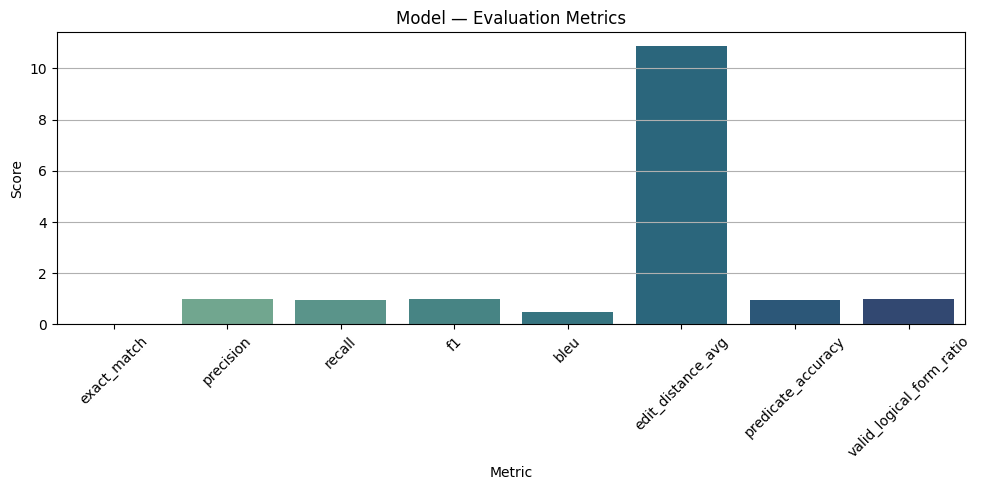

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/rbm/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/rbm/t5-small_gen_metrics.csv
Gen Eval:
  exact_match: 0.0000
  precision: 0.9583
  recall: 0.8794
  f1: 0.9063
  bleu: 0.4052
  edit_distance_avg: 62.5499
  predicate_accuracy: 0.9132
  valid_logical_form_ratio: 0.9994


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,95.83%,87.94%,90.63%,40.52%,62.55,91.32%,99.94%


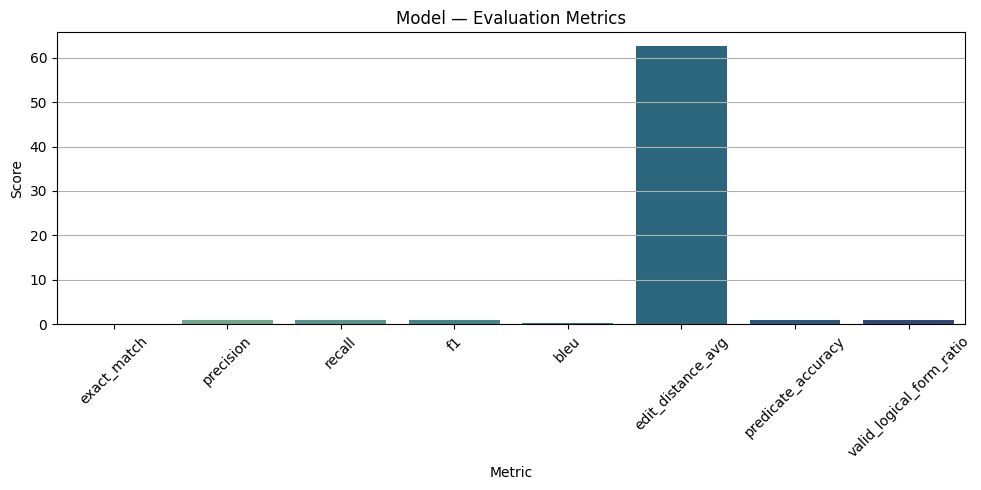

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

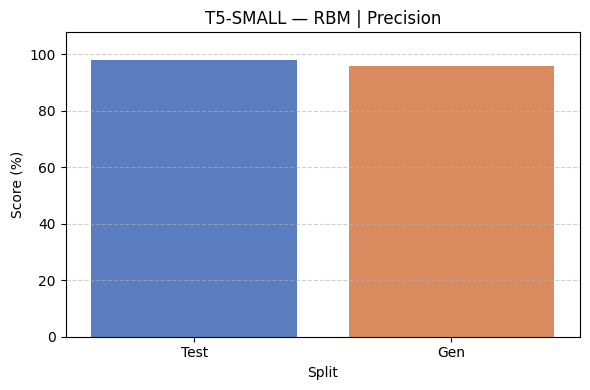

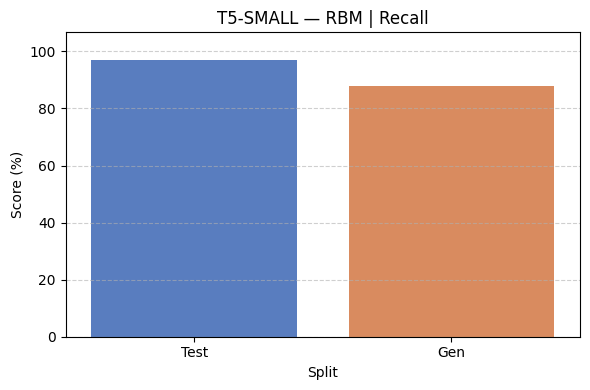

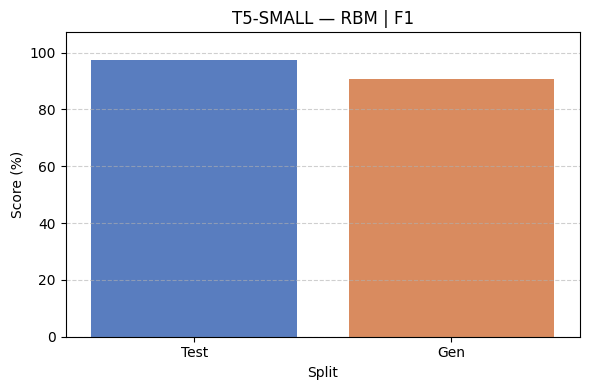

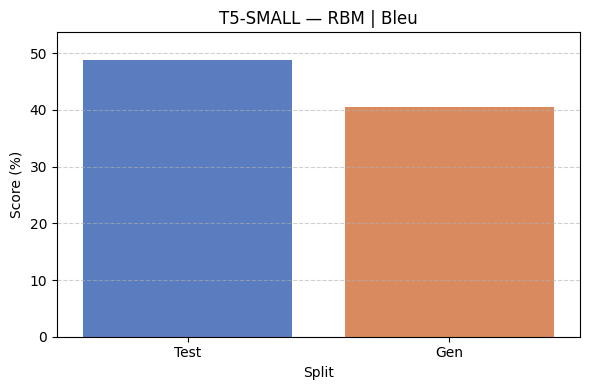

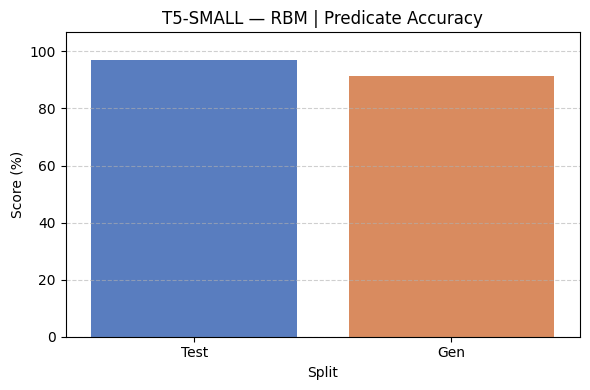

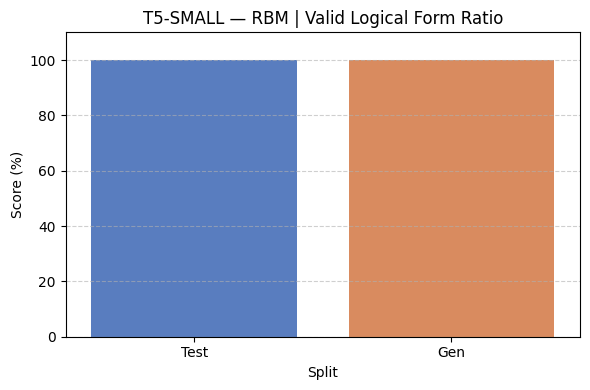

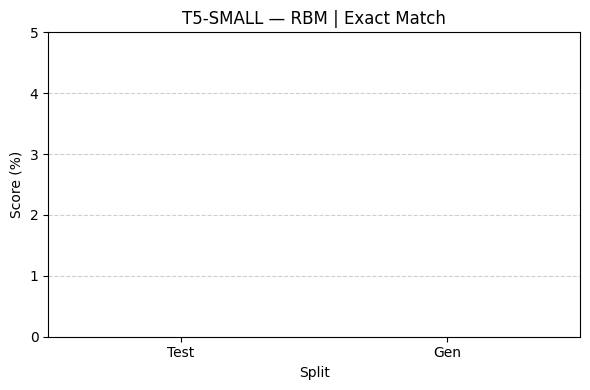

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)